In [1]:
import akshare as ak
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

**确定参数**

In [2]:
股票代码 = '60000'
start_date = "20240306"
end_date = '20250328'
split_ratio = 0.7
window_size = 35  # 滚动窗口的观察区间
decay_factor = 0.7  # 衰减因子，控制权重衰减速度

**导入并整理数据**

In [3]:
source_data = ak.stock_zh_a_hist(symbol=股票代码,period="daily",start_date=start_date,end_date=end_date,adjust='')

In [4]:
data = pd.DataFrame()
data['date'] = source_data['日期']
data['price'] = source_data['收盘']
data['volume'] = source_data['成交量']
data['returns']=np.log(data['price']/data['price'].shift(1))
data['returns_cum'] = np.exp(data['returns'].cumsum())
data.set_index('date', inplace=True)
data.dropna();

**分割训练集**

In [5]:
total_dates = data.index.nunique()
split_index = int(total_dates *split_ratio)
split_date = data.index.unique()[split_index]
train = data[:split_date].copy()
test = data[split_date:].copy()

**查看所有移动均线**

C:\Users\LM_Yuan\AppData\Local\Temp\ipykernel_14816\310988543.py:16: UserWarning: Glyph 45 (-) missing from font(s) SimHei.
  plt.tight_layout(rect=[0, 0.1, 1, 1])
C:\Users\LM_Yuan\AppData\Local\Temp\ipykernel_14816\310988543.py:16: UserWarning: Glyph 46 (.) missing from font(s) SimHei.
  plt.tight_layout(rect=[0, 0.1, 1, 1])
c:\Users\LM_Yuan\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45 (-) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\LM_Yuan\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46 (.) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


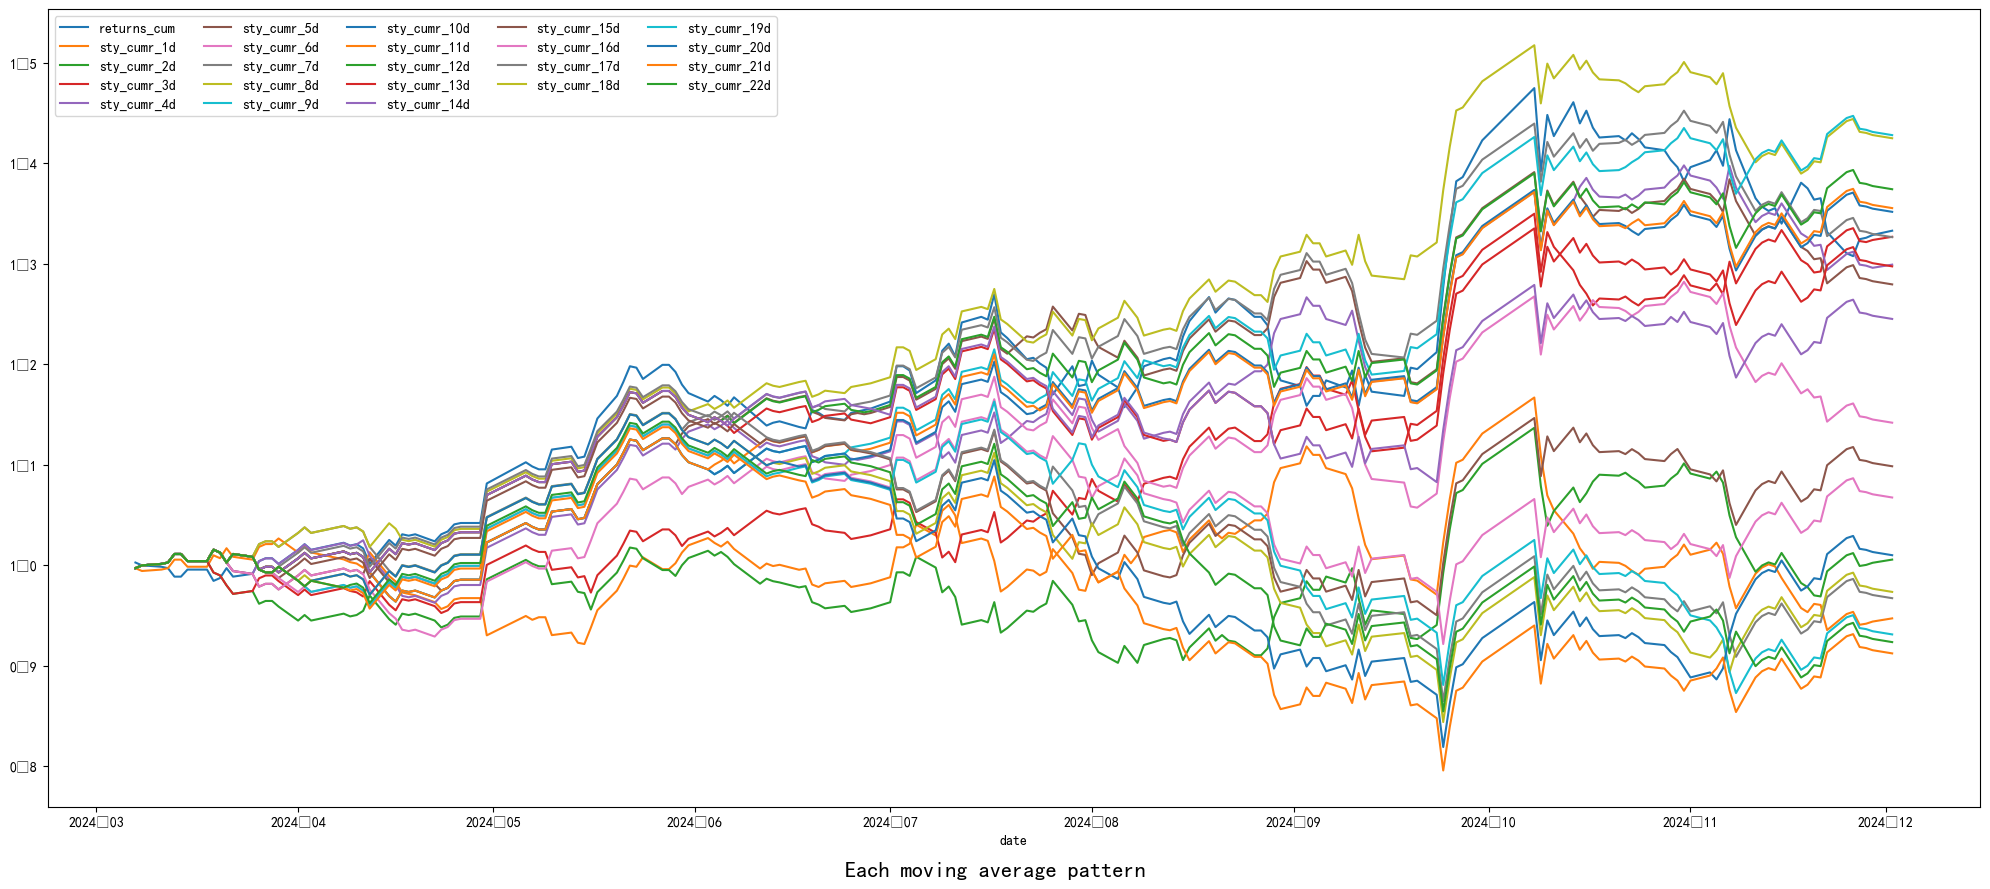

In [6]:
price_plot = ['returns_cum']

for days in range(1, 23):
#     data['position_%d' % days] = np.sign(data['returns'].rolling(days).mean())
    price_plot.append('sty_cumr_%dd' % days)
    train['position_%dd' % days] = np.where(train['returns'].rolling(days).mean()>0,1,-1)
    train['strategy_%dd' % days] = train['position_%dd' % days].shift(1) * train['returns']
    train['sty_cumr_%dd' % days] = train['strategy_%dd' % days].cumsum()+1

ax = train[price_plot].dropna().plot(figsize=(20, 10))
legend = ax.legend(loc='upper left',ncol=5, frameon=True, fontsize=10)

plt.rcParams['axes.unicode_minus'] = False 
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.suptitle('Each moving average pattern', fontsize=16, y=0.1)
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

**测算各移动均线的性能**

In [7]:
mean_returns=[]
std_returns=[]
ratio_mean_std=[]

for days in range(1,23):
    mean_return=train['strategy_%dd'%days].mean()
    std_return=train['strategy_%dd'%days].std()
    mean_returns.append(mean_return)
    std_returns.append(std_return)
    ratio_mean_std.append(mean_return/std_return)

print('Mean Returns:',mean_returns)
print('Standard Deviations:',std_returns)
print('Means/Standard Deviation Ratios:',ratio_mean_std)

Mean Returns: [-0.00029303428853020603, 3.178889190645336e-05, 0.0018156421489819385, 0.0016618462863501684, 0.001552626485990337, 0.0007883582646412967, 0.0018135807847349118, 0.002360284878221779, 0.002377496356577858, 0.0019535936293308426, 0.0019742495681712175, 0.0020785348228778084, 0.0016522873741294586, 0.001361760250690315, 0.0005475486301504797, 0.0003750285623739, -0.00018144318244164053, -0.00014671414616688973, -0.0003816541715758857, 5.61396086075478e-05, -0.0004865099014249622, -0.00042413364619747285]
Standard Deviations: [0.014874455237731206, 0.01487732338998001, 0.014765527234057697, 0.01478372773265446, 0.014795663253509738, 0.014856338262161534, 0.01476578197875873, 0.014687875956946487, 0.014685084281445954, 0.014747810616315705, 0.014745044300620295, 0.014730625398328034, 0.014784805110873905, 0.014814554219504105, 0.014867221765122531, 0.014872603513586095, 0.014876244885083318, 0.014876630066544796, 0.014872434023385594, 0.01487725102854908, 0.01486935618121782

C:\Users\LM_Yuan\AppData\Local\Temp\ipykernel_14816\989709411.py:8: UserWarning: Glyph 45 (-) missing from font(s) SimHei.
  plt.tight_layout(rect=[0, 0.1, 1, 1])
C:\Users\LM_Yuan\AppData\Local\Temp\ipykernel_14816\989709411.py:8: UserWarning: Glyph 46 (.) missing from font(s) SimHei.
  plt.tight_layout(rect=[0, 0.1, 1, 1])


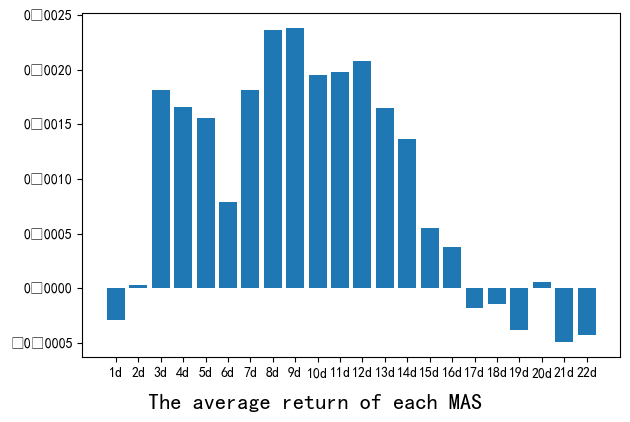

In [8]:
x_labels = ['%dd'% days for days in range(1,23)]

plt.rcParams['axes.unicode_minus'] = False 
plt.rcParams['font.sans-serif'] = ['SimHei'] 

plt.bar(x_labels,mean_returns)
plt.suptitle('The average return of each MAS', fontsize=16, y=0.1)
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

**设定自调节移动均线策略函数**

In [ ]:
def automas_by_mean(df,window_size,decay_factor):
    for days in range(1, 23):
    #     data['position_%d' % days] = np.sign(data['returns'].rolling(days).mean())
        price_plot.append('sty_cumr_%dd' % days)
        df['position_%dd' % days] = np.where(df['returns'].rolling(days).mean()>0,1,-1)
        df['strategy_%dd' % days] = df['position_%dd' % days].shift(1) * df['returns']
        df['sty_cumr_%dd' % days] = df['strategy_%dd' % days].cumsum()+1

    # 1. 创建一个DataFrame存储所有策略的累计收益率
    strategy_return_columns = ['strategy_%dd' % days for days in range(1, 23)]
    all_strategy_returns = df[strategy_return_columns].copy()

    # 2. 找出每个时间点表现最好的策略（基于历史数据）
    # 使用加权滚动窗口计算每个时点的最佳策略
    weights = np.array([decay_factor ** (window_size - i - 1) for i in range(window_size)])
    weights = weights / weights.sum()  # 归一化权重

    best_strategy_by_mean_return = []

    for i in range(len(all_strategy_returns)):
        if i < window_size:
            current_window = all_strategy_returns.iloc[:i+1]
            current_weights = weights[window_size - (i+1):]  # 新增权重调整
            current_weights = current_weights / current_weights.sum()  # 重新归一化
        else:
            current_window = all_strategy_returns.iloc[i-window_size:i]
            current_weights = weights  # 新增权重
        
        if not current_window.empty:
            # 改为计算加权平均收益率（核心修改点）
            mean_returns = (current_window * current_weights[:, np.newaxis]).sum()
            best_strat = mean_returns.idxmax()
        else:
            best_strat = 'strategy_14d'  # 保持原默认策略
        best_strategy_by_mean_return.append(best_strat)
        
    df['best_strategy_mean_return'] = best_strategy_by_mean_return

    # 3. 创建新列存储基于平均收益率选择的最佳策略的每日收益率
    df['auto_strategy_mean_return_position'] = np.nan

    # 4. 为每个时间点分配最佳策略的收益率
    for days in range(1, 23):
        mask = df['best_strategy_mean_return'] == f'strategy_{days}d'
        df.loc[mask, 'auto_strategy_mean_return_position'] = df.loc[mask, f'position_{days}d']
        df.loc[mask, 'auto_strategy'] = df.loc[mask, 'returns'] * df[f'position_{days}d'].shift(1)
    
    return df[['auto_strategy_mean_return_position', 'auto_strategy']]

**使用自调节移动均线函数**

In [10]:
automas_by_mean(train,window_size,decay_factor);

**设定策略应用函数**

In [11]:
def gra_analyze(df):
    # Set English fonts and style
    plt.style.use('seaborn-v0_8')
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['axes.unicode_minus'] = False
    
    # ======================
    # 1. Trading Position Plot
    # ======================
    plt.figure(figsize=(25, 3))
    df['auto_strategy_mean_return_position'].plot(ylim=[-1.1, 1.1])
    plt.title('Trading Position (1=Long, -1=Short)')
    plt.ylabel('Position')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # ======================
    # 2. Performance Metrics
    # ======================
    metrics = pd.DataFrame()
    
    # Basic statistics
    metrics['Mean'] = df[['returns', 'auto_strategy']].mean()
    metrics['Std Dev'] = df[['returns', 'auto_strategy']].std()
    metrics['Coeff of Variation'] = metrics['Mean'] / metrics['Std Dev']
    metrics['Total Return'] = df[['returns', 'auto_strategy']].sum()
    
    # Calculate max drawdown
    df['cumret'] = df['auto_strategy'].cumsum().apply(np.exp)
    df['cummax'] = df['cumret'].cummax()
    max_drawdown = (df['cummax'] - df['cumret']).max()
    metrics.loc['auto_strategy', 'Max Drawdown'] = max_drawdown
    
    print("Performance Metrics:")
    print(metrics.round(4))
    print(f"\nStrategy Max Drawdown: {max_drawdown:.2%}")
    
    # ======================
    # 3. Price/Volume Plots
    # ======================
    buy = df[df['auto_strategy_mean_return_position'] == 1]
    sell = df[df['auto_strategy_mean_return_position'] == -1]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(25, 12))
    
    # Price plot
    ax1.plot(df['price'], label='Price')
    ax1.scatter(buy.index, buy['price'], color='red', label='Buy Signal')
    ax1.scatter(sell.index, sell['price'], color='green', label='Sell Signal')
    ax1.set_ylabel('Price')
    ax1.legend()
    ax1.grid(True)
    
    # Volume plot
    ax2.bar(buy.index, buy['volume'], color='red', label='Buy Volume')
    ax2.bar(sell.index, sell['volume'], color='green', label='Sell Volume')
    ax2.set_ylabel('Volume')
    ax2.legend()
    ax2.grid(True)
    
    plt.suptitle('Price and Volume with Trading Signals', y=0.92)
    plt.tight_layout()
    plt.show()
    
    # ======================
    # 4. Cumulative Returns
    # ======================
    plt.figure(figsize=(25, 8))
    df[['cumret', 'cummax']].plot()
    plt.title('Cumulative Returns vs Peak Returns')
    plt.ylabel('Returns')
    plt.legend(['Cumulative Returns', 'Peak Returns'])
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # ======================
    # 5. Strategy Comparison
    # ======================
    plt.figure(figsize=(25, 12))
    
    df['passive_cumret'] = df['returns'].cumsum().apply(np.exp)
    df['auto_strategy_cumret'] = df['auto_strategy'].cumsum().apply(np.exp)
    
    ax1 = plt.gca()
    ax2 = ax1.twinx()
    
    # Passive investment
    ax2.plot(df['passive_cumret'], 
            label='Passive Investment', 
            color='#FF6B00',
            linewidth=4,
            alpha=0.8,
            zorder=3)
    
    # Dynamic strategy
    ax2.plot(df['auto_strategy_cumret'], 
            label='Dynamic Strategy', 
            color='#E51937',
            linewidth=3,
            linestyle='--',
            zorder=2)
    
    # MA strategies
    colors = plt.cm.Greys(np.linspace(0.3, 0.7, 22))
    for days in range(1, 23):
        ax2.plot(df[f'sty_cumr_{days}d'], 
                 color=colors[days-1],
                 alpha=0.4,
                 linewidth=1,
                 zorder=1)
    
    # Best MA strategy
    strategy_performance = {}
    for days in range(1, 23):
        final_return = df[f'sty_cumr_{days}d'].iloc[-1]
        strategy_performance[days] = final_return
    top_strategy = max(strategy_performance.items(), key=lambda x: x[1])
    
    days, return_value = top_strategy
    ax2.plot(df[f'sty_cumr_{days}d'], 
             label=f'Best MA Strategy: {days}D (Return:{return_value-1:.1%})',
             color='#1F77B4',
             alpha=0.8,
             linewidth=3,
             zorder=2)
    
    # Trading zones
    ax1.fill_between(df.index, 
                    df['price'].min()*0.98, 
                    df['price'].max()*1.02,
                    where=(df['auto_strategy_mean_return']==1),
                    color='green', alpha=0.05, label='Long Zone')
    ax1.fill_between(df.index,
                     df['price'].min()*0.98,
                     df['price'].max()*1.02,
                     where=(df['auto_strategy_mean_return']==-1),
                     color='red', alpha=0.05, label='Short Zone')
    
    ax1.set_ylabel('Price')
    ax2.set_ylabel('Cumulative Returns')
    ax1.tick_params(axis='y', colors='black')
    ax2.tick_params(axis='y', colors='blue')
    
    plt.title('Strategy Performance Comparison', pad=20)
    ax1.grid(True, linestyle='--', alpha=0.3)
    
    # Legend handling
    handles, labels = [], []
    for ax in [ax1, ax2]:
        for h, l in zip(*ax.get_legend_handles_labels()):
            if l not in labels:
                handles.append(h)
                labels.append(l)
    plt.legend(handles, labels, loc='upper left', ncol=3)
    
    # Performance annotations
    max_passive = df['passive_cumret'].max()
    max_strategy = df['auto_strategy_cumret'].max()
    plt.annotate(f'Passive Max: {max_passive-1:.1%}',
                xy=(df['passive_cumret'].idxmax(), max_passive),
                xytext=(15, 15), textcoords='offset points',
                arrowprops=dict(arrowstyle='->'))
    plt.annotate(f'Strategy Max: {max_strategy-1:.1%}',
                xy=(df['auto_strategy_cumret'].idxmax(), max_strategy),
                xytext=(-60, 15), textcoords='offset points',
                arrowprops=dict(arrowstyle='->'))
    
    plt.tight_layout()
    plt.show()
    
    return metrics

**应用并测算策略性能**

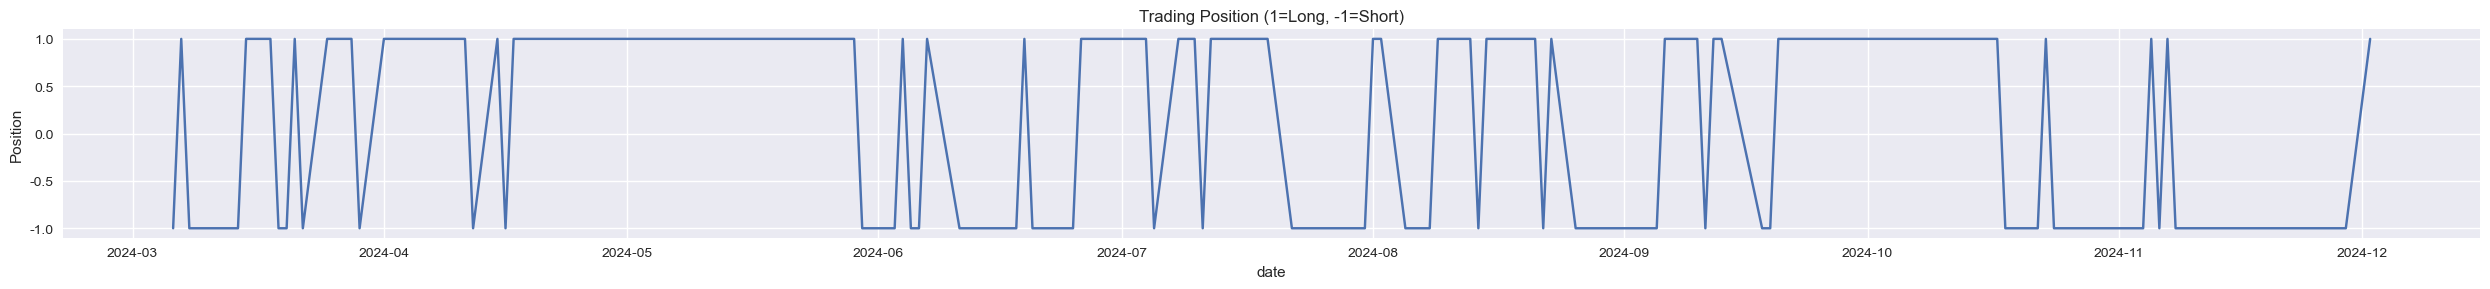

Performance Metrics:
                 Mean  Std Dev  Coeff of Variation  Total Return  Max Drawdown
returns        0.0016   0.0148              0.1079        0.2873           NaN
auto_strategy  0.0026   0.0146              0.1800        0.4744        0.1398

Strategy Max Drawdown: 13.98%


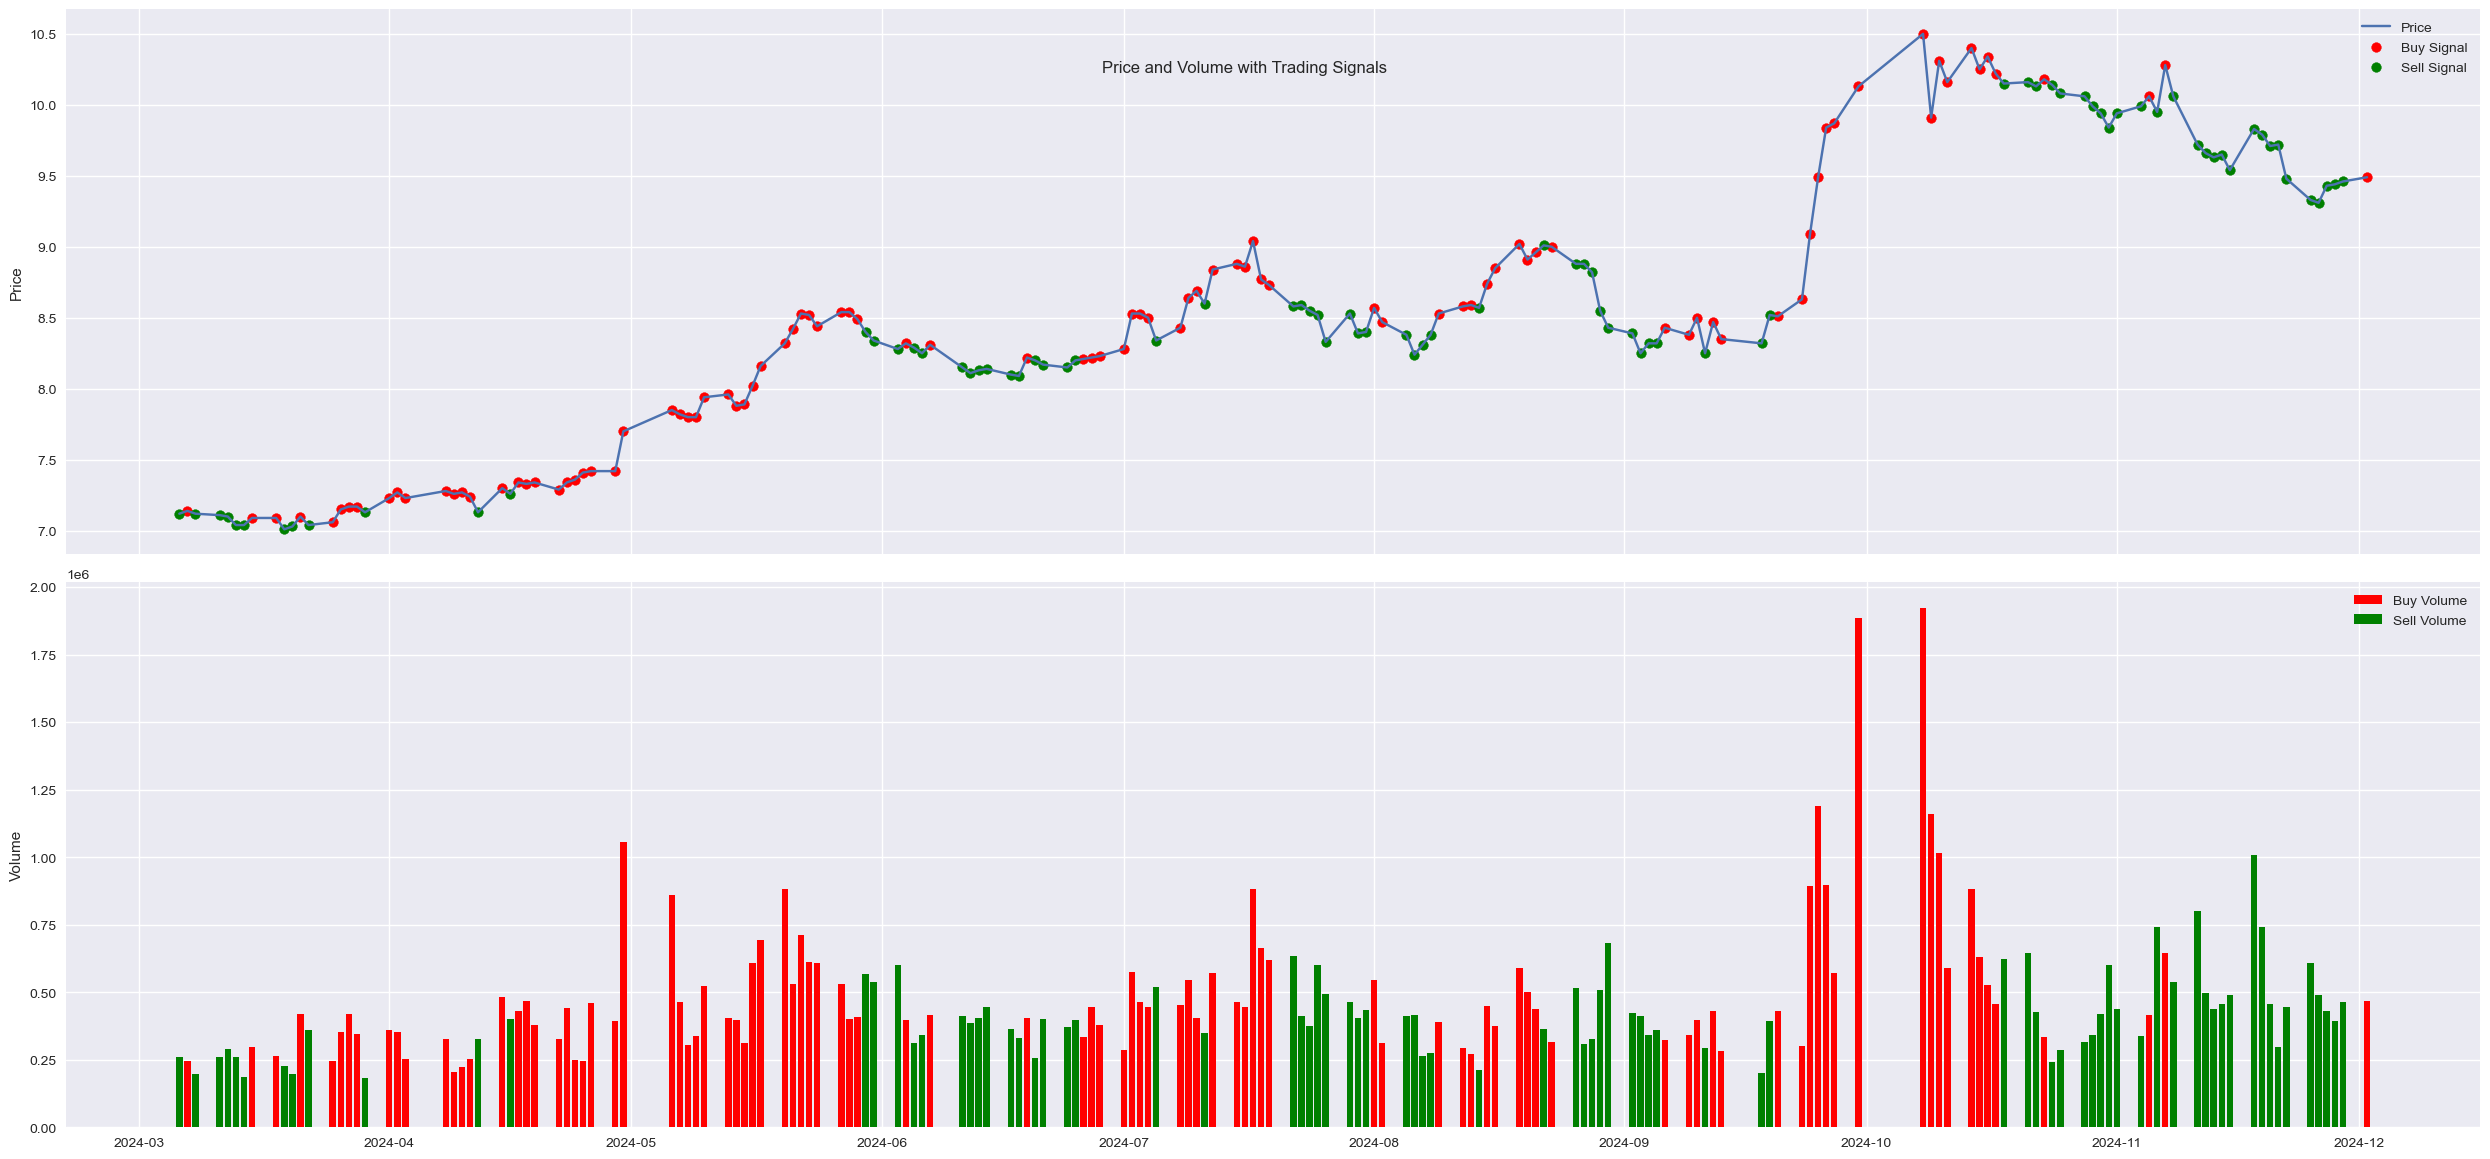

<Figure size 2500x800 with 0 Axes>

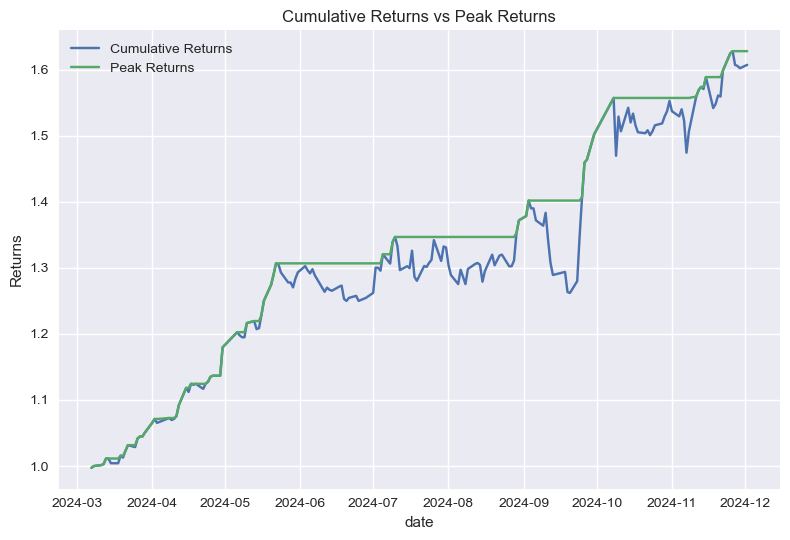

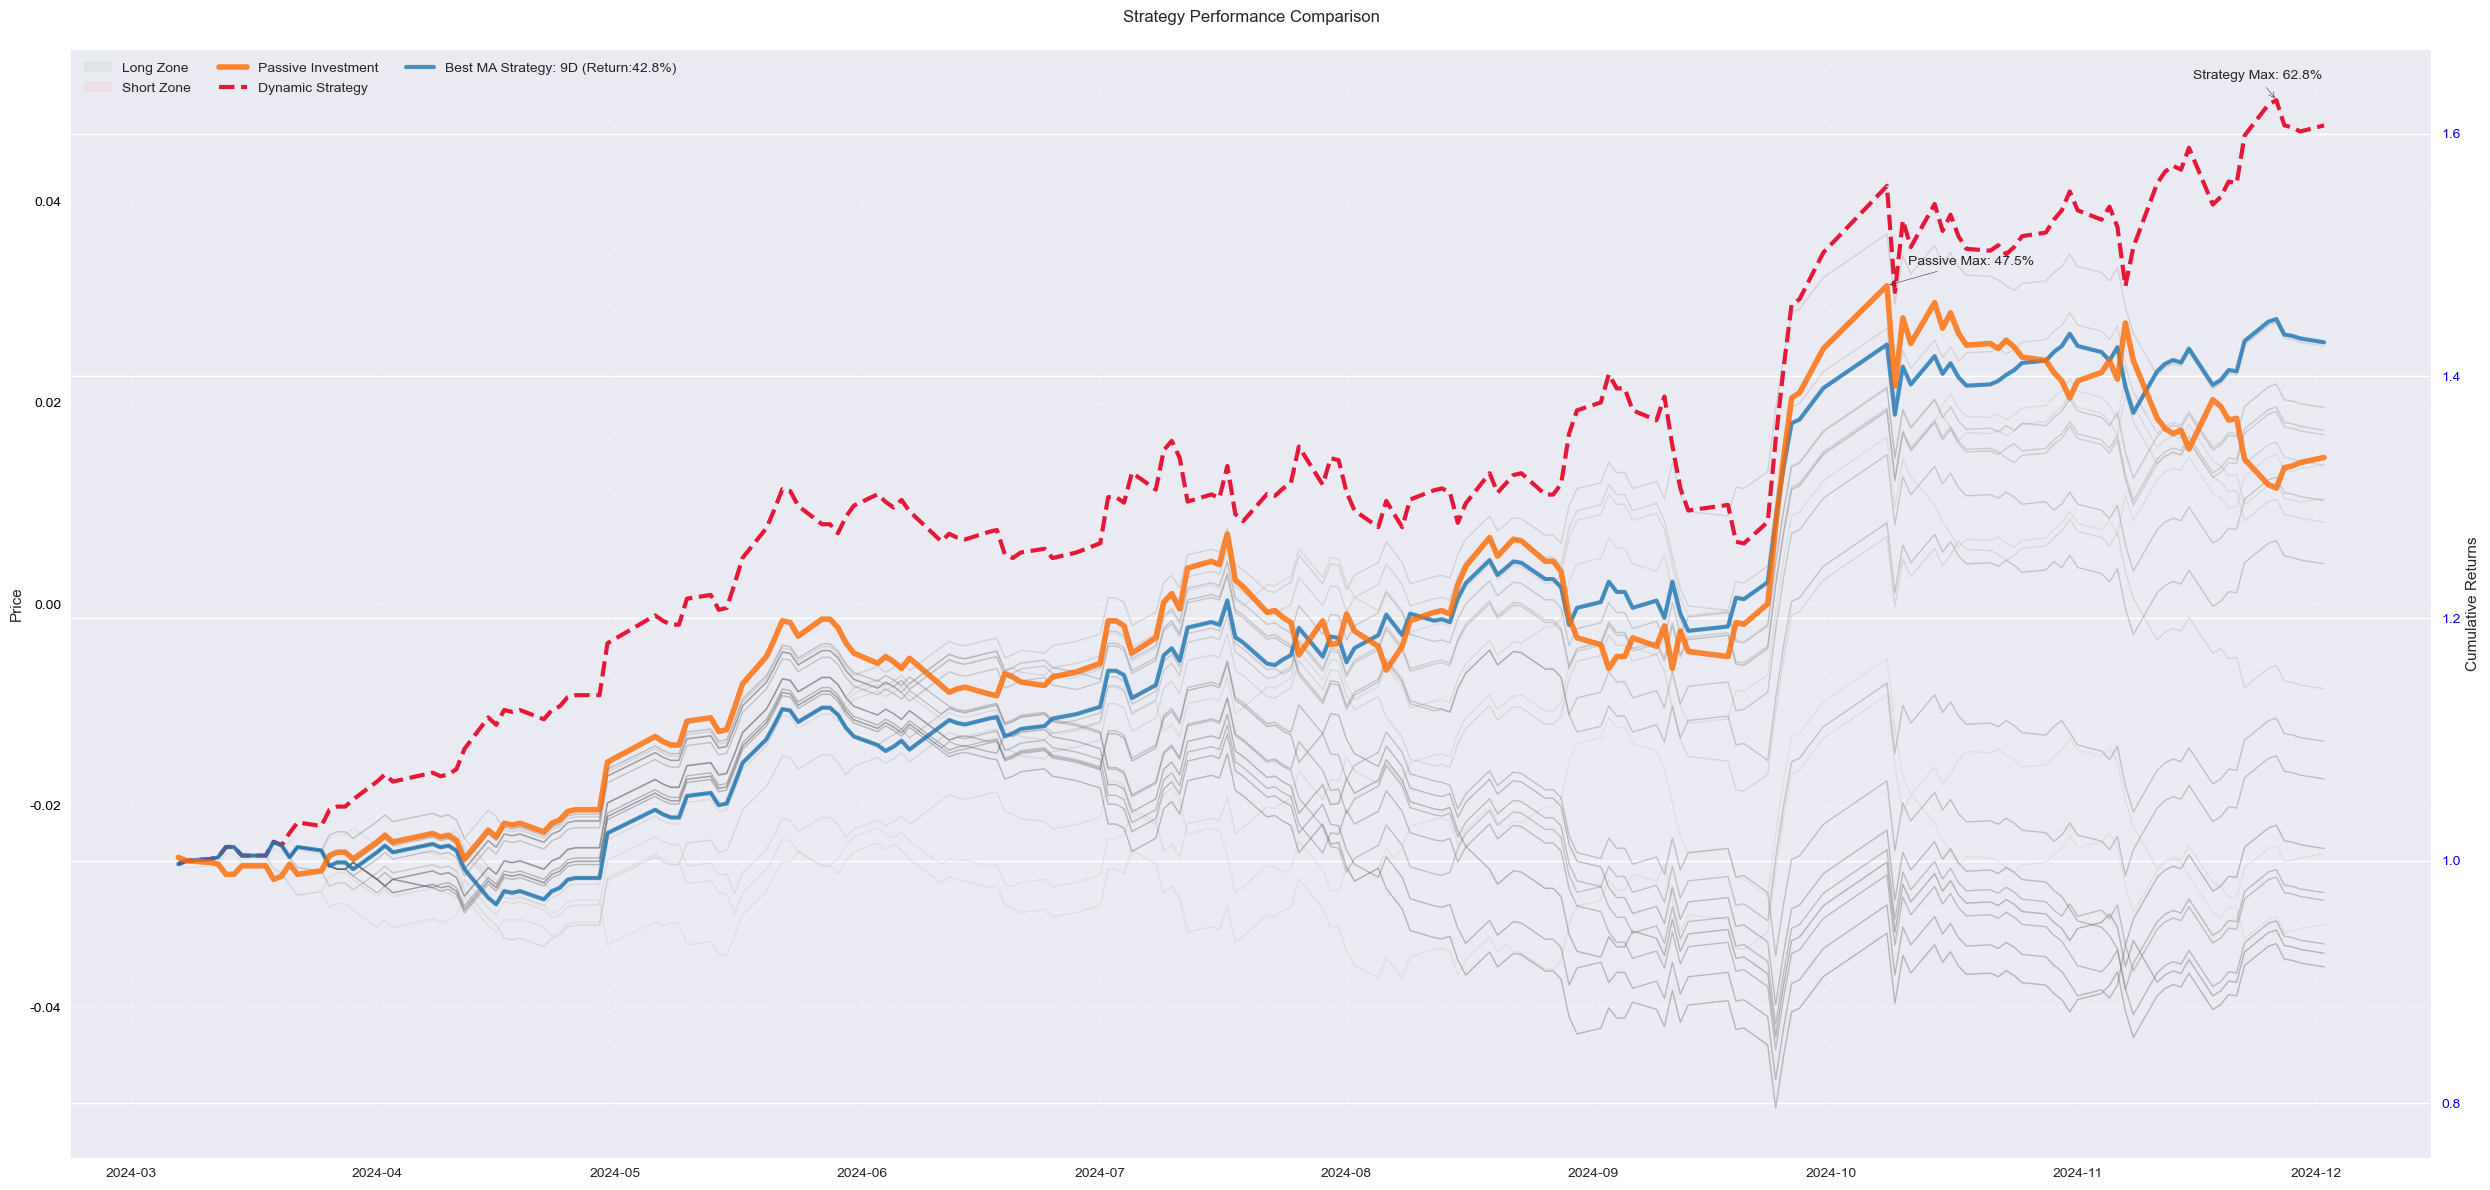

,Mean,Std Dev,Coeff of Variation,Total Return,Max Drawdown
returns,0.001596,0.014791,0.107923,0.287331,NaN
auto_strategy,0.002635,0.014641,0.180011,0.474388,0.139821


In [12]:
gra_analyze(train)

**使用测试集进行检验**

In [13]:
automas_by_mean(test,window_size,decay_factor);

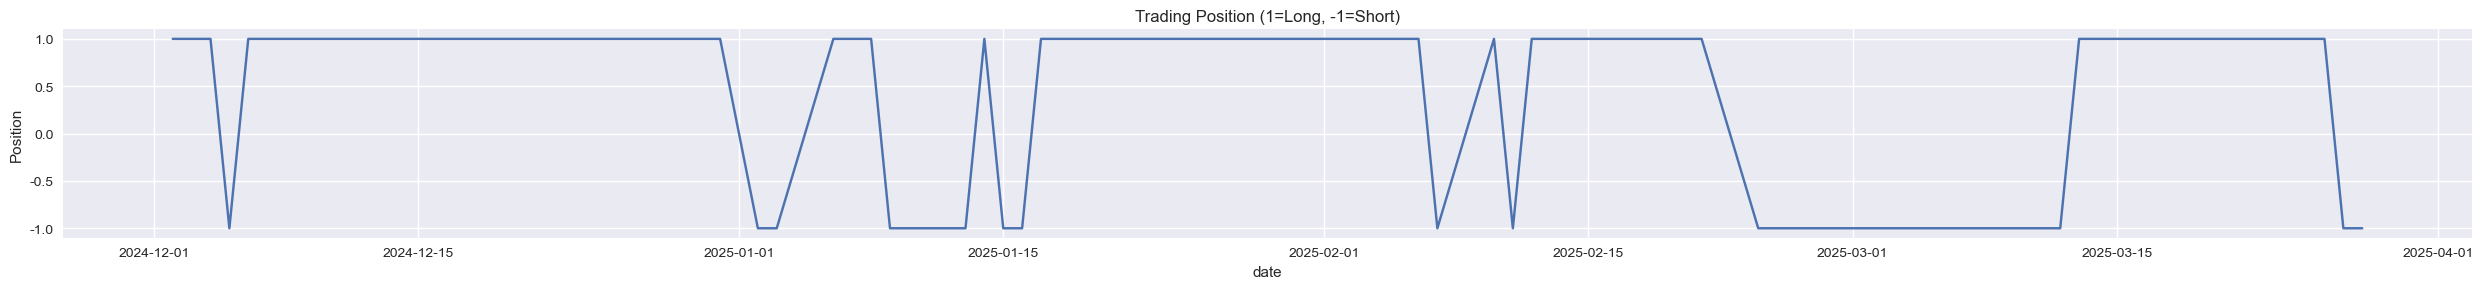

Performance Metrics:
                 Mean  Std Dev  Coeff of Variation  Total Return  Max Drawdown
returns        0.0013   0.0126              0.1002        0.0986           NaN
auto_strategy  0.0017   0.0126              0.1384        0.1346        0.1993

Strategy Max Drawdown: 19.93%


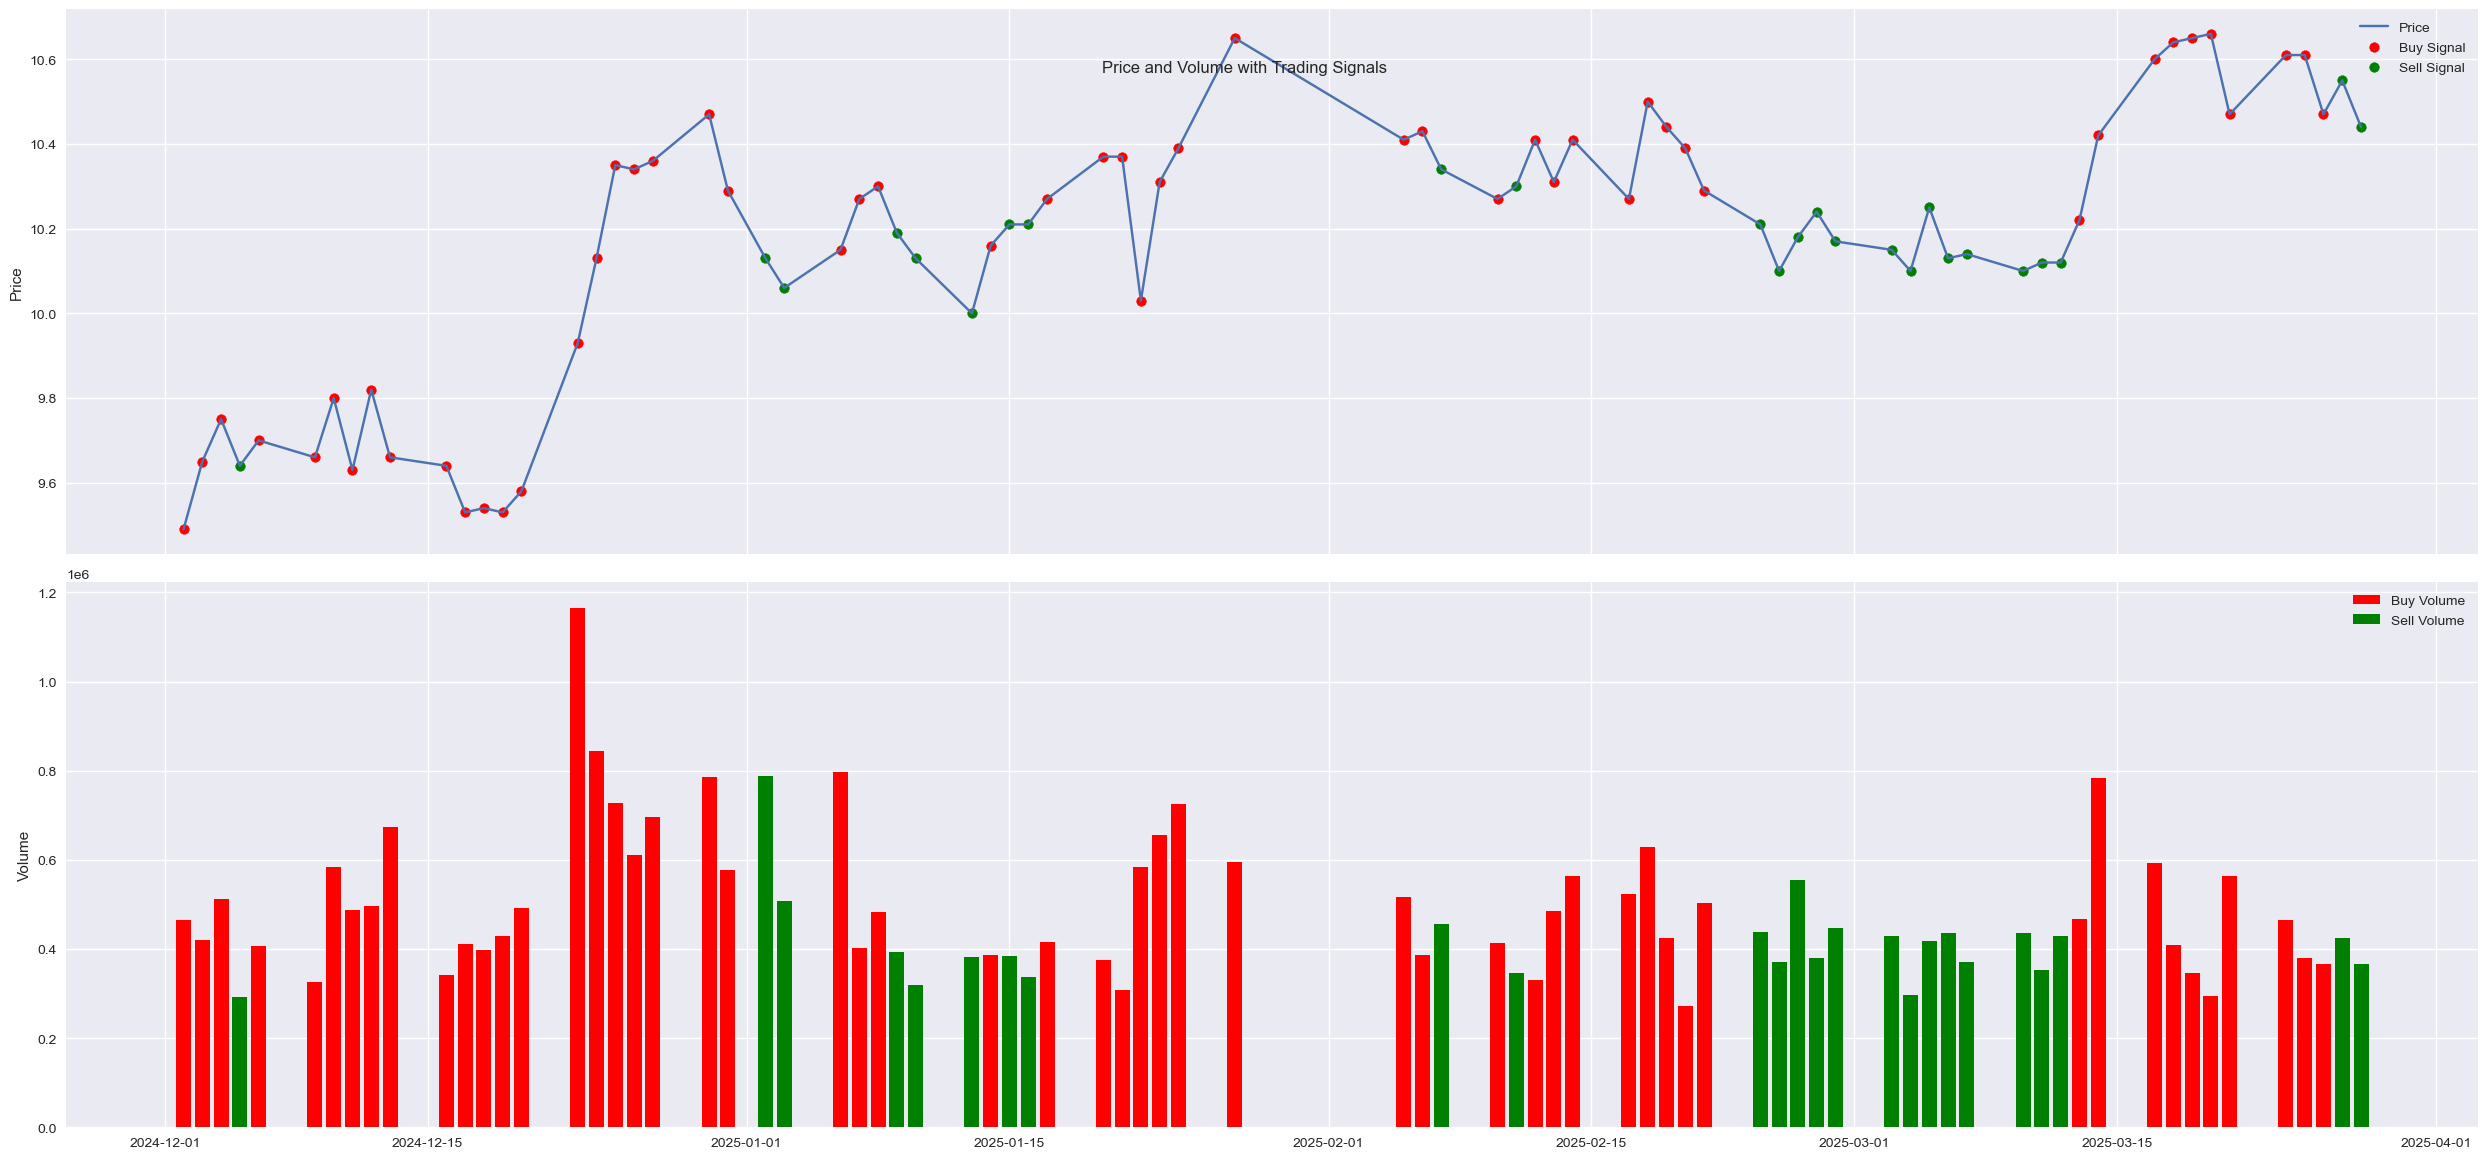

<Figure size 2500x800 with 0 Axes>

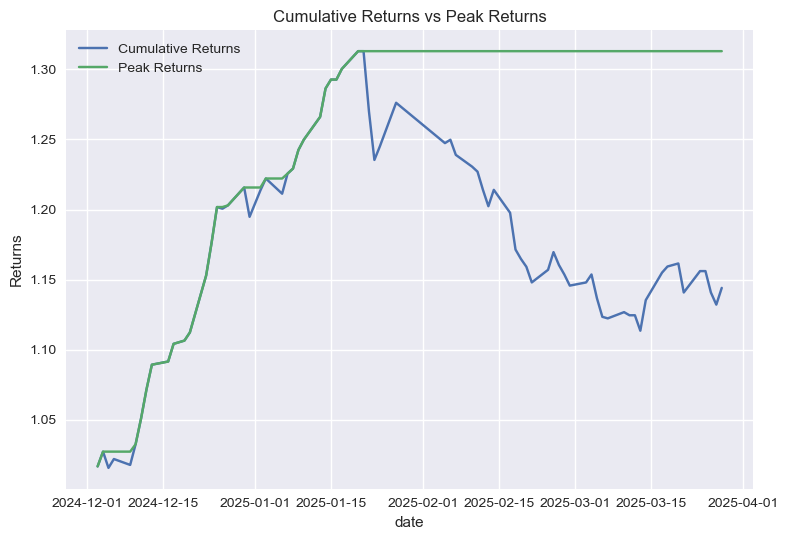

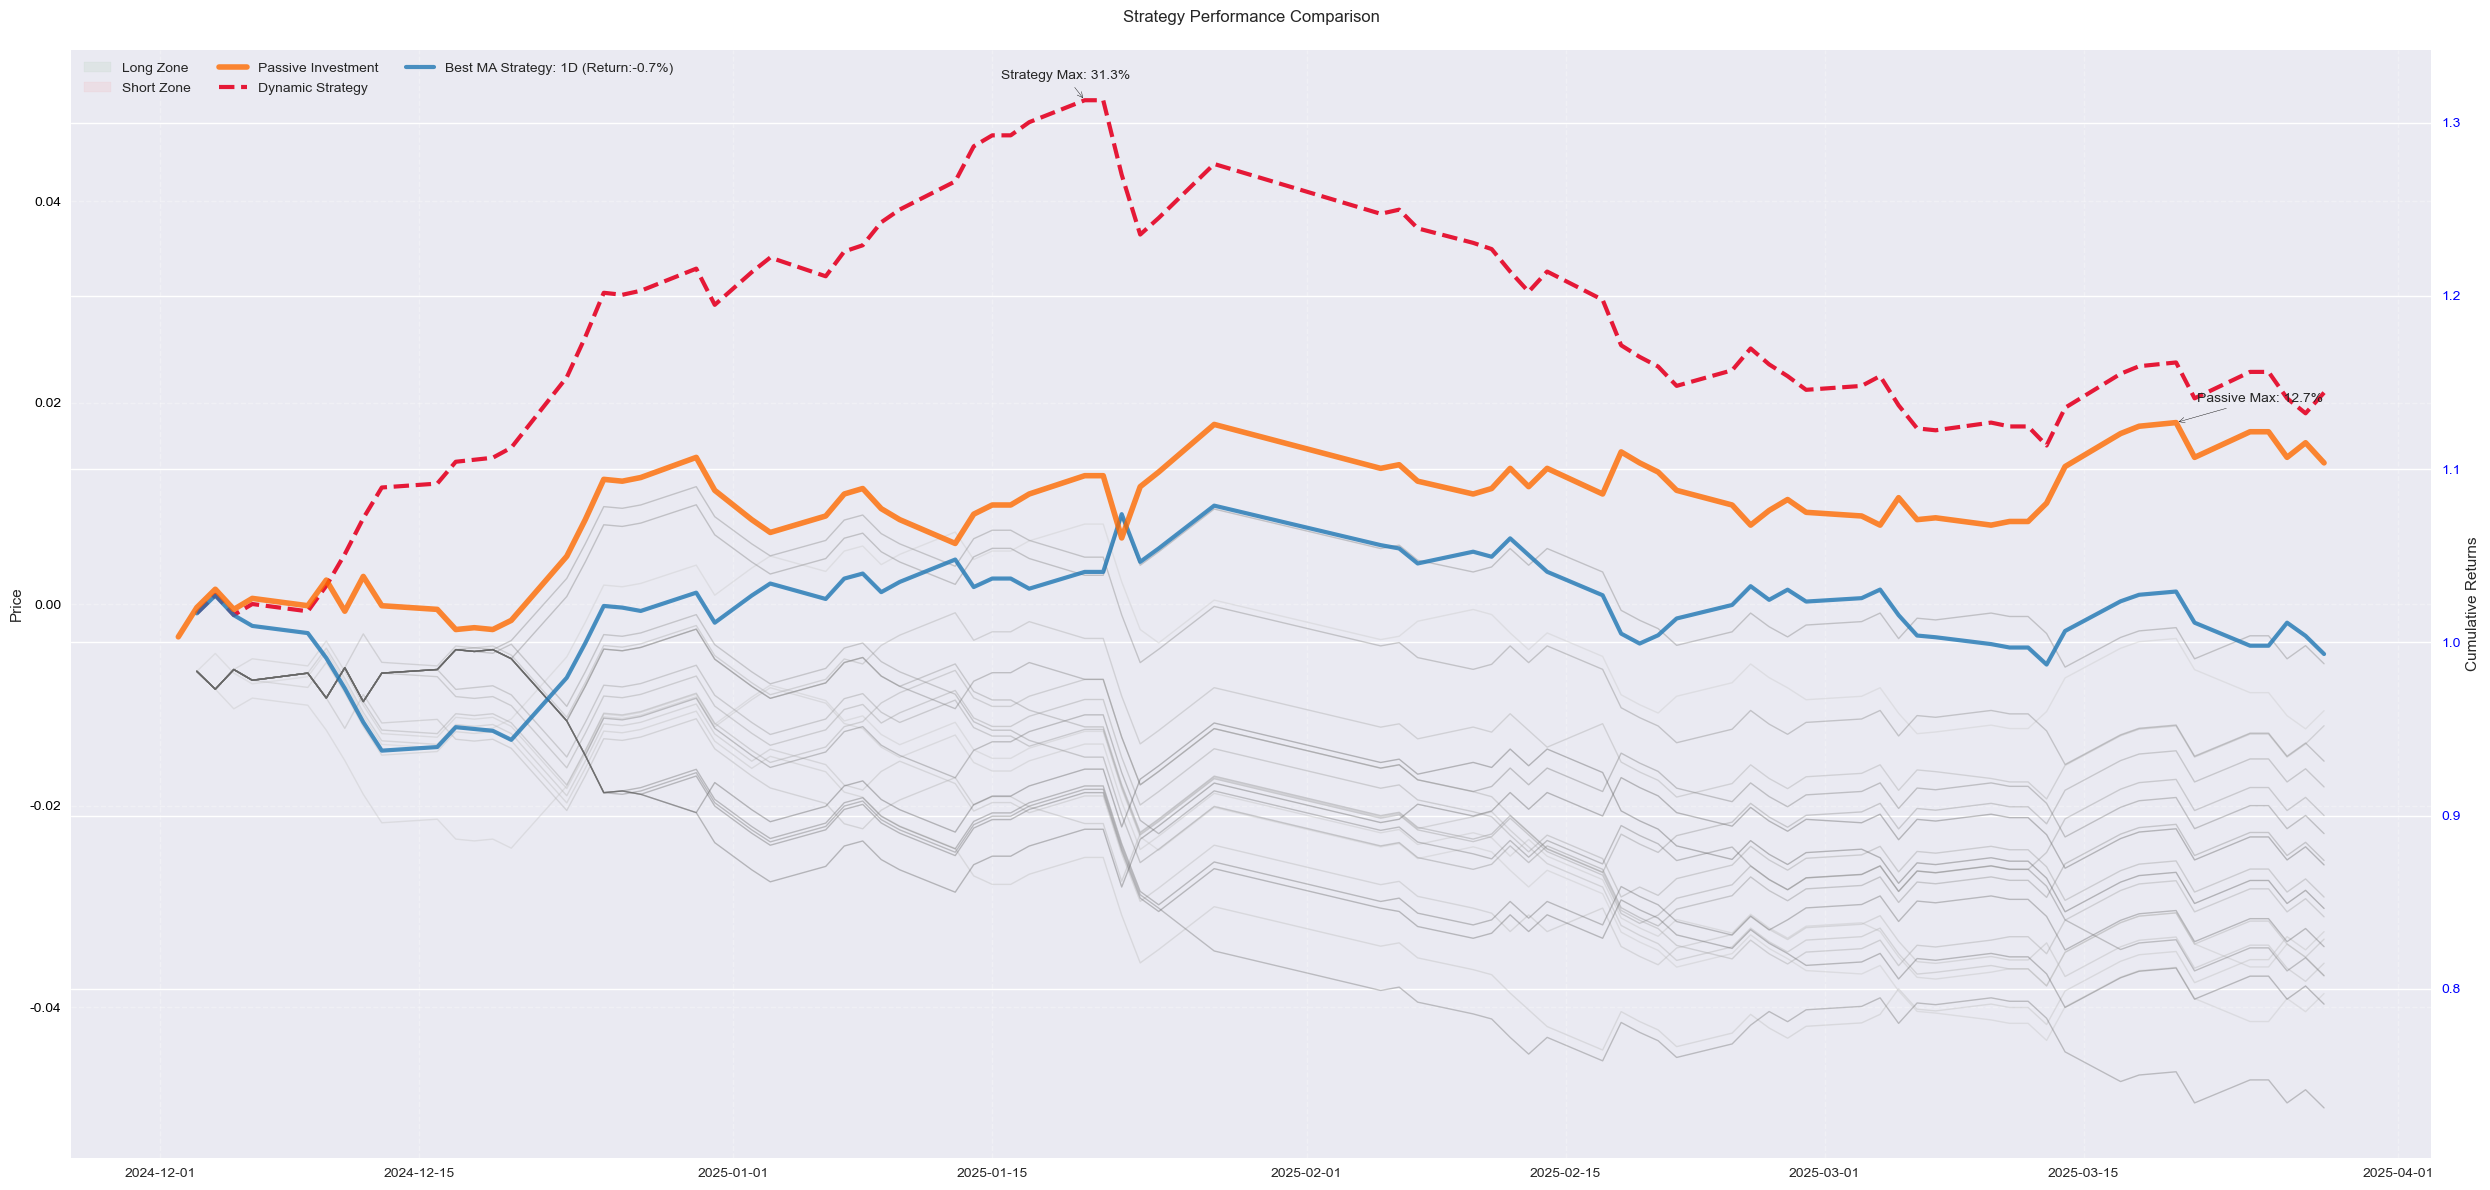

,Mean,Std Dev,Coeff of Variation,Total Return,Max Drawdown
returns,0.001264,0.012618,0.100157,0.098572,NaN
auto_strategy,0.001749,0.012638,0.138368,0.134646,0.199293


In [14]:
gra_analyze(test)

In [17]:
print("数据校验：")
print("收益率前5行：\n", data['returns'].head())
print("收益率统计：\n", data['returns'].describe())
print("价格序列长度：", len(data))

数据校验：
收益率前5行：
 date
2024-03-06         NaN
2024-03-07    0.002805
2024-03-08   -0.002805
2024-03-11   -0.001405
2024-03-12   -0.001407
Name: returns, dtype: float64
收益率统计：
 count    257.000000
mean       0.001489
std        0.014173
min       -0.057831
25%       -0.006780
50%        0.000000
75%        0.008742
max        0.051930
Name: returns, dtype: float64
价格序列长度： 258
